# 1. - Cкачиваем обученные модели и репозиторий

In [1]:
!gdown --id 1iwtQkcf5l4c-iBOQpeIOsl3B5or-qeeF
!gdown --id 15A1Y1kohvQHxarerbRe9wtgNjBsb1uwb
!gdown --id 12aJFw2gpPWV8Ah_rE_4tMDzmT3zABqek
!gdown --id 1PhvlkaANaBpoAe_YcsMJgcShMB_z617H

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1iwtQkcf5l4c-iBOQpeIOsl3B5or-qeeF
From (redirected): https://drive.google.com/uc?id=1iwtQkcf5l4c-iBOQpeIOsl3B5or-qeeF&confirm=t&uuid=78ea6991-742d-47b3-90bf-44f045232fcf
To: /content/sft_grpo.zip
100% 332M/332M [00:09<00:00, 33.8MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=15A1Y1kohvQHxarerbRe9wtgNjBsb1uwb
From (redirected): https://drive.google.com/uc?id=15A1Y1kohvQHxarerbRe9wtgNjBsb1uwb&confirm=t&uuid=4cfa2c6a-c1d7-4012-9533-832b30faa0e7
To: /content/grpo_only.zip


In [2]:
!unzip -q -o grpo_only.zip -d /extracted_data/
!unzip -q -o sft_grpo.zip -d /extracted_data/
!unzip -q -o sft_only.zip -d /extracted_data/
!unzip -q -o srft_model.zip -d /extracted_data/

In [3]:
%cd /content
!rm -rf HW-2_env
!git clone https://github.com/TebelevGt/HW-2_env.git
%cd HW-2_env
# Переключаемся на нужную ветку ПЕРЕД переходом в подпапку rl-shortest-path-agent
!git checkout HW_3_hybrid_rl
%cd rl-shortest-path-agent

/content
Cloning into 'HW-2_env'...
remote: Enumerating objects: 577, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 577 (delta 95), reused 198 (delta 73), pack-reused 354 (from 1)
Receiving objects: 100% (577/577), 11.95 MiB | 13.05 MiB/s, done.
Resolving deltas: 100% (261/261), done.
/content/HW-2_env
Branch 'HW_3_hybrid_rl' set up to track remote branch 'HW_3_hybrid_rl' from 'origin'.
Switched to a new branch 'HW_3_hybrid_rl'
/content/HW-2_env/rl-shortest-path-agent


# 2. - Логика импортов

In [4]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1" # [NEW] Extra 30% context lengths!
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install or uv pip install
    !pip install unsloth vllm
else:
    pass # For Colab / Kaggle, we need extra instructions hidden below \/

In [5]:
#@title Colab Extra Install { display-mode: "form" }
#%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; _numpy = f'numpy=={numpy.__version__}'; _pil = f'pillow=={PIL.__version__}'
    except: _numpy = "numpy"; _pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    _vllm, _triton = ('vllm==0.9.2', 'triton==3.2.0') if is_t4 else ('vllm==0.15.1', 'triton')
    !uv pip install -qqq --upgrade {_vllm} {_numpy} {_pil} torchvision bitsandbytes xformers unsloth
    !uv pip install -qqq {_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2

Using Python 3.12.12 environment at: /usr
Resolved 18 packages in 32ms
Uninstalled 2 packages in 110ms
Installed 2 packages in 81ms
 - huggingface-hub==1.6.0
 + huggingface-hub==0.36.2
 - transformers==5.2.0
 + transformers==4.56.2
Using Python 3.12.12 environment at: /usr
Resolved 1 package in 1ms
Uninstalled 1 package in 2ms
Installed 1 package in 7ms
 - trl==0.24.0
 + trl==0.22.2


In [6]:
import os
import torch
import gc
from unsloth import FastLanguageModel
from envs import evaluate_agent
import json

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 03-08 08:36:07 [__init__.py:244] Automatically detected platform cuda.
ERROR 03-08 08:36:10 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!


# 3. - Валидация моделей

In [11]:
def evaluate_checkpoints(checkpoint_dirs, datasets, max_seq_length=8192):
    """
    Последовательно тестирует список чекпоинтов на списке датасетов.
    Если чекпоинт не найден, загружается базовая модель.
    """
    all_results = {}

    # ВСТАВКА: Оборачиваем в enumerate, чтобы знать индекс чекпоинта
    for idx, ckpt in enumerate(checkpoint_dirs):
        model_name = ckpt if os.path.exists(ckpt) else "unsloth/Qwen2.5-0.5B-Instruct"
        print(f"\n🚀 Loading: {model_name} (Requested: {ckpt})")

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_name,
            max_seq_length=max_seq_length,
            load_in_4bit=True,
        )
        FastLanguageModel.for_inference(model)
        tokenizer.padding_side = "left"

        all_results[ckpt] = {}

        # ВСТАВКА: Проверяем, является ли текущий чекпоинт последним в списке
        is_last_ckpt = (idx == len(checkpoint_dirs) - 1)

        for ds_path in datasets:
            print(f"🔎 Eval on: {ds_path}")

            # ВСТАВКА: Условие срабатывает, только если это нужный датасет И последняя модель
            is_pass128 = False #("hard_val_128" in ds_path) and is_last_ckpt
            n_samples = 12 if is_pass128 else 1
            bs = 1 if is_pass128 else 8

            if is_pass128:
                print("⚠️ Включен режим pass@128 (128 сэмплов, батч 1)")
            else:
                print("⚡ Включен быстрый режим (1 сэмпл, батч 8)")

            res = evaluate_agent(
                model=model,
                tokenizer=tokenizer,
                dataset=ds_path,
                device="cuda",
                batch_size=bs,            # Передаем динамический батч
                n_samples=n_samples       # Передаем количество сэмплов
            )
            all_results[ckpt][ds_path] = res
            print(f"✅ Result: {res}")

        del model, tokenizer
        gc.collect()
        torch.cuda.empty_cache()

    return all_results

# Использование:
checkpoint_dirs = ["unsloth/Qwen2.5-0.5B-Instruct","/extracted_data/grpo_only","/extracted_data/sft_only","/extracted_data/sft_grpo","/extracted_data/srft_model"]
datasets = ['data/hard128k/hard_val_128.pkl']
results = evaluate_checkpoints(checkpoint_dirs, datasets)


🚀 Loading: /extracted_data/srft_model (Requested: /extracted_data/srft_model)
==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
🔎 Eval on: data/hard128k/hard_val_128.pkl
⚡ Включен быстрый режим (1 сэмпл, батч 8)


Evaluating (Batched): 100%|██████████| 16/16 [10:20<00:00, 38.79s/it]


✅ Result: {'accuracy': 0.1875, 'format_compliance': 0.828125, 'hallucination_rate': 0.5859375, 'wrong_endpoint_rate': 0.0546875, 'optimal_rate': 0.1328125, 'pass@1': 0.1328125, 'avg_optimality_gap': 1.2916666666666667, 'avg_reasoning_len': 868.828125}


# 4. - Визуализация

/tmp/ipykernel_195/383262967.py:101: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("results_dashboard.png", dpi=300, bbox_inches='tight')


✅ Дашборд успешно сгенерирован и сохранен как 'results_dashboard.png'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


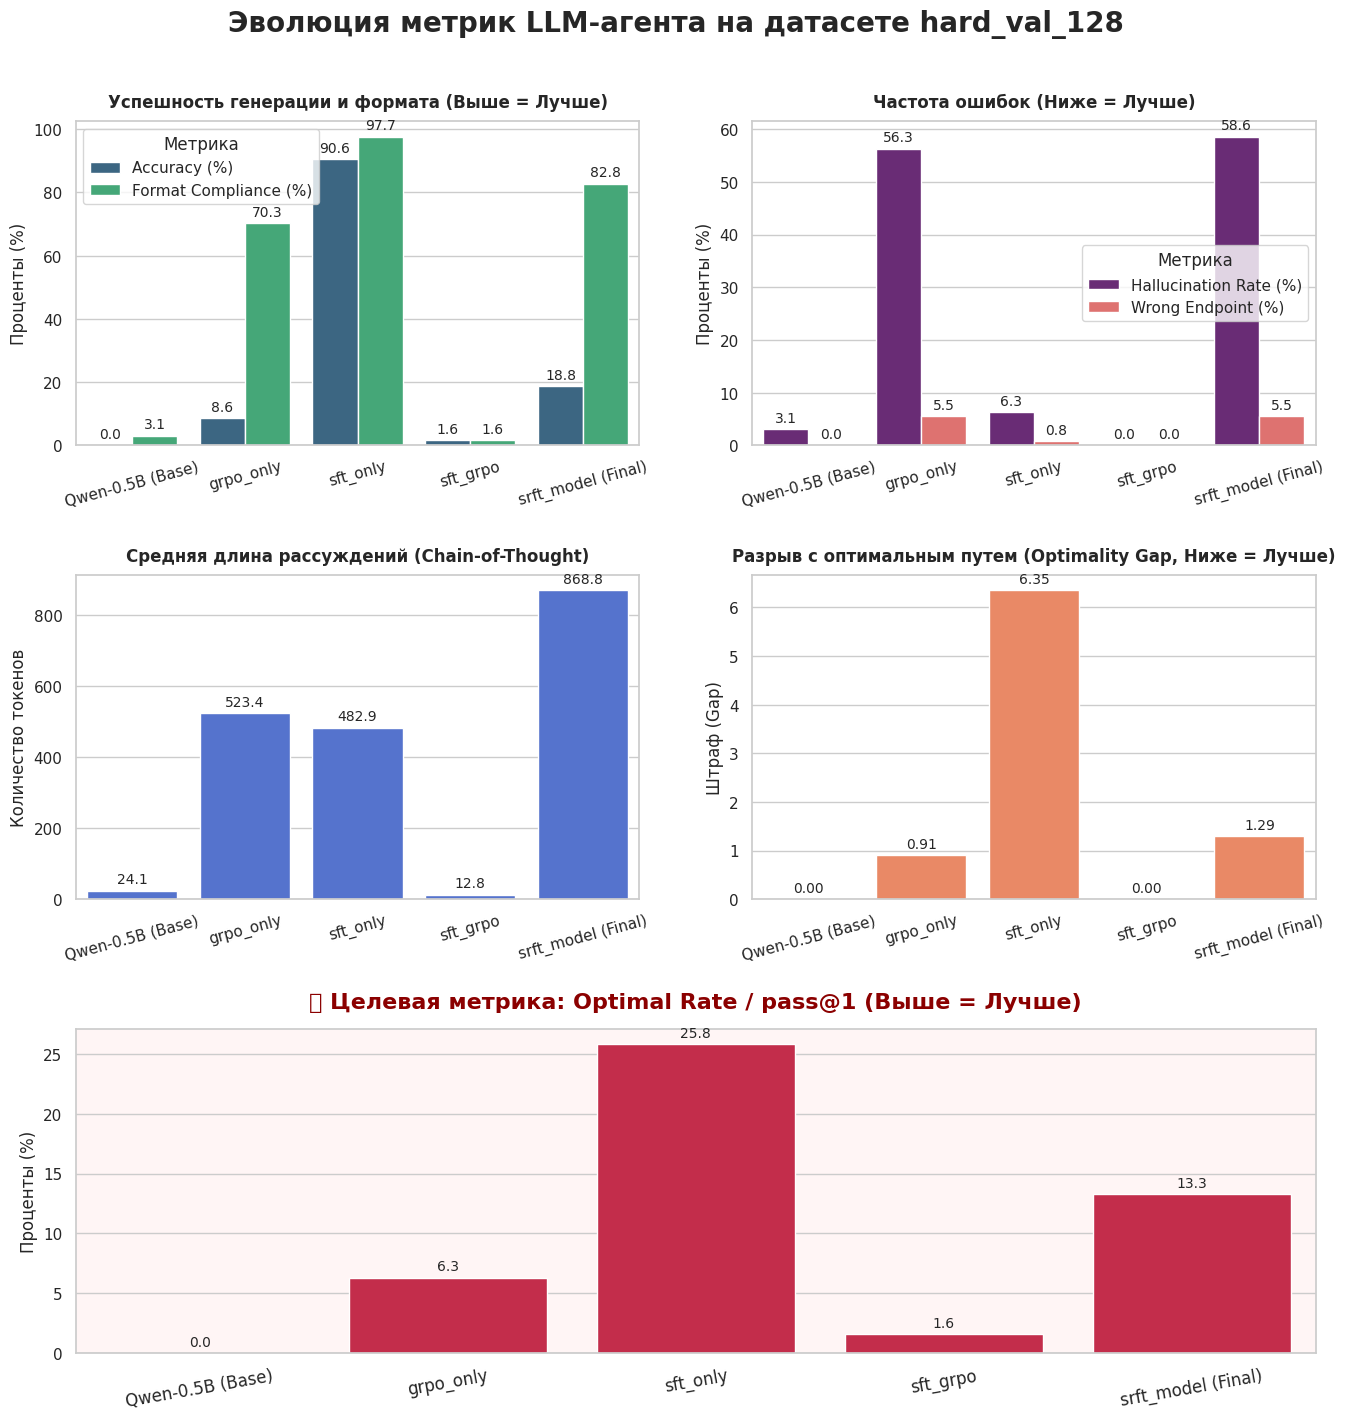

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Данные из итоговой таблицы
data = {
    "Модель": ["Qwen-0.5B (Base)", "grpo_only", "sft_only", "sft_grpo", "srft_model (Final)"],
    "Accuracy (%)": [0.0, 8.6, 90.6, 1.6, 18.8],
    "Format Compliance (%)": [3.1, 70.3, 97.7, 1.6, 82.8],
    "Hallucination Rate (%)": [3.1, 56.3, 6.3, 0.0, 58.6],
    "Wrong Endpoint (%)": [0.0, 5.5, 0.8, 0.0, 5.5],
    "Optimal Rate (pass@1) (%)": [0.0, 6.3, 25.8, 1.6, 13.3],
    "Avg Optimality Gap": [0.0, 0.91, 6.35, 0.0, 1.29],
    "Avg Reasoning Len": [24.1, 523.4, 482.9, 12.8, 868.8]
}

df = pd.DataFrame(data)

# 2. Настройка стиля дашборда
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Создаем фигуру с кастомной сеткой (3 строки, 2 колонки)
fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.2)

# Вспомогательная функция для подписей над столбцами
def add_labels(ax, fmt='%.1f'):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=10)

# ==========================================
# График 1: Успешность (Левый верхний)
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
df_success = df.melt(id_vars="Модель", value_vars=["Accuracy (%)", "Format Compliance (%)"],
                     var_name="Метрика", value_name="Значение")
sns.barplot(data=df_success, x="Модель", y="Значение", hue="Метрика", palette="viridis", ax=ax1)
ax1.set_title("Успешность генерации и формата (Выше = Лучше)", fontweight='bold', pad=10)
ax1.set_ylabel("Проценты (%)")
ax1.set_xlabel("")
ax1.tick_params(axis='x', rotation=15)
add_labels(ax1)

# ==========================================
# График 2: Ошибки (Правый верхний)
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
df_errors = df.melt(id_vars="Модель", value_vars=["Hallucination Rate (%)", "Wrong Endpoint (%)"],
                    var_name="Метрика", value_name="Значение")
sns.barplot(data=df_errors, x="Модель", y="Значение", hue="Метрика", palette="magma", ax=ax2)
ax2.set_title("Частота ошибок (Ниже = Лучше)", fontweight='bold', pad=10)
ax2.set_ylabel("Проценты (%)")
ax2.set_xlabel("")
ax2.tick_params(axis='x', rotation=15)
add_labels(ax2)

# ==========================================
# График 3: Длина рассуждений (Левый средний)
# ==========================================
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(data=df, x="Модель", y="Avg Reasoning Len", color="royalblue", ax=ax3)
ax3.set_title("Средняя длина рассуждений (Chain-of-Thought)", fontweight='bold', pad=10)
ax3.set_ylabel("Количество токенов")
ax3.set_xlabel("")
ax3.tick_params(axis='x', rotation=15)
add_labels(ax3)

# ==========================================
# График 4: Оптимальность пути (Правый средний)
# ==========================================
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(data=df, x="Модель", y="Avg Optimality Gap", color="coral", ax=ax4)
ax4.set_title("Разрыв с оптимальным путем (Optimality Gap, Ниже = Лучше)", fontweight='bold', pad=10)
ax4.set_ylabel("Штраф (Gap)")
ax4.set_xlabel("")
ax4.tick_params(axis='x', rotation=15)
add_labels(ax4, fmt='%.2f')

# ==========================================
# График 5: ВЫДЕЛЕННЫЙ pass@1 (Нижний ряд, на всю ширину)
# ==========================================
# Объединяем ячейки сетки [2, :] чтобы график занял всю ширину
ax5 = fig.add_subplot(gs[2, :])
# Используем яркий, контрастный цвет для привлечения внимания
sns.barplot(data=df, x="Модель", y="Optimal Rate (pass@1) (%)", color="crimson", ax=ax5)
ax5.set_title("🎯 Целевая метрика: Optimal Rate / pass@1 (Выше = Лучше)",
              fontsize=16, fontweight='bold', color='darkred', pad=15)
ax5.set_ylabel("Проценты (%)", fontsize=12)
ax5.set_xlabel("")
ax5.tick_params(axis='x', rotation=10, labelsize=12)
add_labels(ax5)

# Добавляем общую рамку/фон для акцента на нижнем графике
ax5.set_facecolor('#fff5f5') # Слегка розоватый фон для контраста

# 3. Финализация и сохранение
fig.suptitle("Эволюция метрик LLM-агента на датасете hard_val_128",
             fontsize=20, fontweight='bold', y=0.95)

plt.savefig("results_dashboard.png", dpi=300, bbox_inches='tight')
print("✅ Дашборд успешно сгенерирован и сохранен как 'results_dashboard.png'")
plt.show()